# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

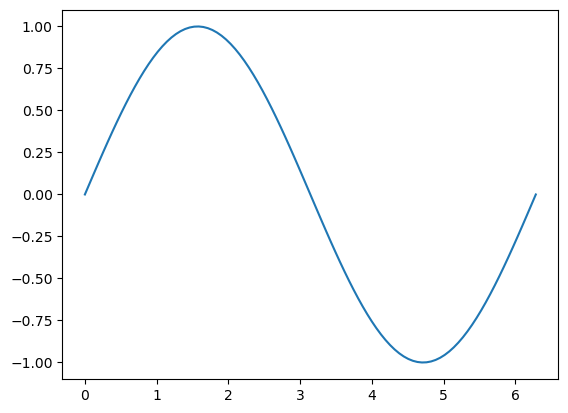

In [1]:
#1) Draw a staticwave
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

#turn into animation
fig, ax = plt.subplots()
line, = ax.plot(x, np.sin(x))

def update(frame):
    """
    updating sin wave by shifting it horizontally
    frame(integer) = current frame number, increasing with time 
    line, (tuple) = updated line object (being redrawn)
    """
    line.set_ydata(np.sin(x + frame / 10.0))
    return line,

ani = animation.FuncAnimation(fig, update, frames = 100, interval = 25, blit =True) #Divided the interval by 1/2 in order to make animation 2X faster
plt.show()

In [ ]:
# To make the wave move 2 times faster I needed to change the interval to be 25 instead of 50, 
#this is becuase by decreasing the time in miliseconds between frames we increase the number of frames per second, making the animation faster

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [16]:
ani.save("animation.gif", writer="pillow", fps=40)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [ ]:
"""
If blit=True , FuncAnimation must return an iterable of all artists that were modified or created. 
This information is used by the blitting algorithm to determine which parts of the figure have to be updated. 
The return value is unused if blit=False and may be omitted.
"""

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

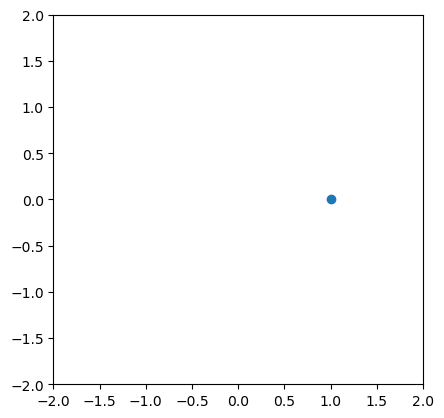

In [23]:
r = 1 #radius of circle
def circle(a): #a is angle
    return np.array([r*np.cos(a), r*np.sin(a)])

fig, ax = plt.subplots()
ax.axis([-2, 2, -2, 2])
ax.set_aspect("equal")
point, = ax.plot(0, 1, marker="o")

def update(a):
    x, y = circle(a)
    point.set_data([x], [y])
    return point, 

ani = animation.FuncAnimation(fig, update, interval=5, blit=True, repeat=True, frames=np.linspace(0,2*np.pi,360, endpoint=False))

plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [ ]:
ani.save("animation.gif", writer="pillow", fps=40)

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [3]:
G = 6.67 * (10**-11)
Ms = 1.989 * (10**30)
Me = 5.972 * (10**24)
Mm = 6.39 * (10**23)
Mc = 6.39e20
AU = 1.496e11
daysec = 86400

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [6]:
e_ap_v = 29300
m_ap_v = 24000
commet_v = 7000

Run the cell below to define some gravitational constants because we expect no mass loss:

In [9]:
# your code here
gravconst_e = G * Me * Ms
gravconst_m = G * Mm * Ms
gravconst_c = G * Mc * Ms

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [12]:
xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [15]:
xve, yve, zve = 0, e_ap_v, 0
xvm, yvm, zvm = 0, m_ap_v, 0
xvc, yvc, zvc = 0, commet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [18]:
xs, ys, zs = 0, 0, 0
xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [21]:
t = 0
dt = 1 * daysec
years = 5
sim_years = years * 365 * daysec

Create empty lists to store all of your varibles. Run the cell below.

In [26]:
xelist, yelist = [], []
xmlist, ymlist = [], []
xclist, yclist = [], []
xslist, yslist = [], []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [51]:
while t < sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)
    
    t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

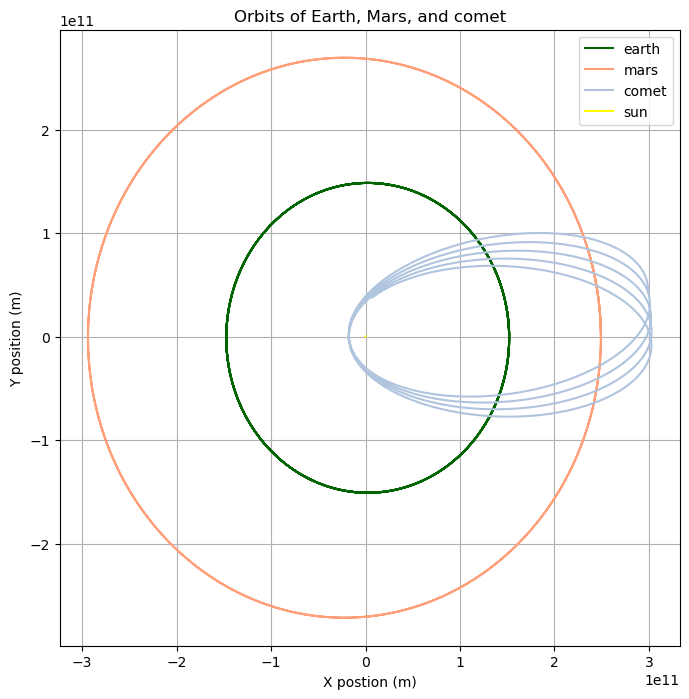

In [78]:
fig, ax = plt.subplots(figsize=(8,8)) #creating fig

plt.plot(xelist,yelist, color = "darkgreen", label = "earth")
plt.plot(xmlist, ymlist, color = "lightsalmon", label = "mars")
plt.plot(xclist, yclist, color = "lightsteelblue", label = "comet")
plt.plot(xslist, yslist, markersize = 10, color = "yellow", label = "sun")
plt.xlabel("X postion (m)")
plt.ylabel("Y position (m)")

plt.title("Orbits of Earth, Mars, and comet")

plt.grid(True)

plt.legend()

plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_e, = ax.plot(xelist,yelist, '-g', lw=1, color = "darkgreen")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_m, = ax.plot(xmlist,ymlist, '-g', lw=1, color = "lightsalmon")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_c, = ax.plot(xclist,yclist, '-g', lw=1, color = "lightsteelblue")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:9: UserWarning: color is redundantly defined by the '

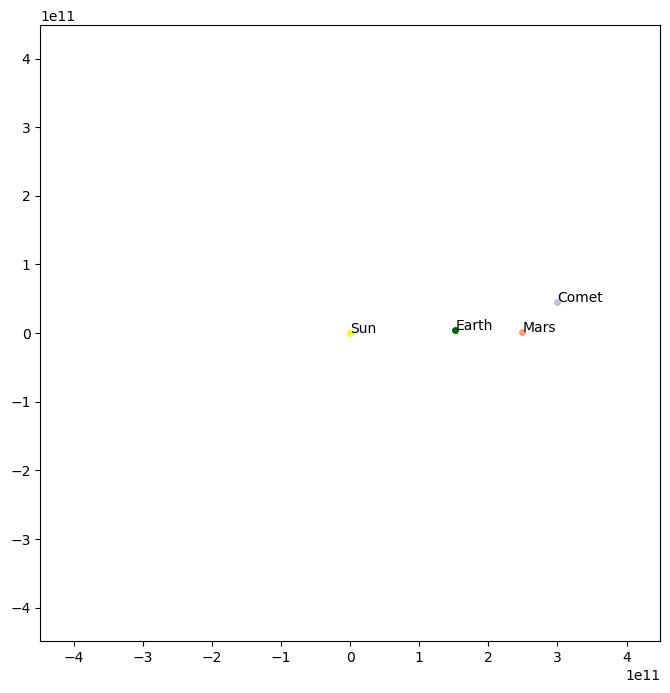

In [53]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8,8))

#unpacking the lines:
line_e, = ax.plot(xelist,yelist, '-g', lw=1, color = "darkgreen")
line_m, = ax.plot(xmlist,ymlist, '-g', lw=1, color = "lightsalmon")
line_c, = ax.plot(xclist,yclist, '-g', lw=1, color = "lightsteelblue")
line_s, = ax.plot(xslist,yslist, '-g', lw=1, color = "yellow")

#unpacking points:
point_e, = ax.plot(xelist,yelist,'bo',markersize=4, color = "darkgreen")
point_m, = ax.plot(xmlist,ymlist,'bo',markersize=4, color = "lightsalmon")
point_c, = ax.plot(xclist,yclist,'bo',markersize=4, color = "lightsteelblue")
point_s, = ax.plot(xslist,yslist,'bo',markersize=4, color = "yellow")

#text for object
text_e = ax.text(AU,0,'Earth')
text_m = ax.text(AU,0,'Mars')
text_c = ax.text(AU,0,'Comet')
text_s = ax.text(AU,0,'Sun')

plt.xlim(-3 * AU, 3 * AU)
plt.ylim(-3 * AU, 3 * AU)

def update(frame):
    """
    will update each of the lines, points and pieces of text
    """
    #earth
    line_e.set_data(xelist[:frame], yelist[:frame])
    point_e.set_data(xelist[frame], yelist[frame])
    text_e.set_position((xelist[frame],yelist[frame]))

    #mars
    line_m.set_data(xmlist[:frame], ymlist[:frame])
    point_m.set_data(xmlist[frame], ymlist[frame])
    text_m.set_position((xmlist[frame],ymlist[frame]))

    #comet
    line_c.set_data(xclist[:frame], yclist[:frame])
    point_c.set_data(xclist[frame], yclist[frame])
    text_c.set_position((xclist[frame],yclist[frame]))

    #sun
    line_s.set_data(xslist[:frame], yslist[:frame])
    point_s.set_data(xslist[frame], yslist[frame])
    text_s.set_position((xslist[frame],yslist[frame]))
    
    return line_e, line_m, line_c, line_s, point_e, point_m, point_c, point_s, text_e, text_m, text_c, text_s,

ani = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit =True)
plt.show()

In [55]:
ani.save("orbits.gif", writer="pillow", fps=10)

C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:32: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xelist[frame], yelist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:37: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xmlist[frame], ymlist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:42: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_c.set_data(xclist[frame], yclist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\1679058518.py:47: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_s.set_data(xslist[frame], ysl

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

In [49]:
#variable set up
Mmr = 3.285 * (10**23)
Mj = 1.898 * (10**27)

mr_ap_v = 39000
j_ap_v = 13070

gravconst_mr = G * Mmr * Ms
gravconst_j = G * Mj * Ms

xmr, ymr, zmr = 0.466 * AU, 0, 0
xj, yj, zj = 5.45 * AU, 0, 0

xvmr, yvmr, zvmr = 0, mr_ap_v, 0
xvj, yvj, zvj = 0, j_ap_v, 0

xmrlist, ymrlist = [], []
xjlist, yjlist = [], []

while t < sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)

    #MERCURY
    rx, ry, rz = xmr - xs, ymr - ys, zmr - zs
    modr3_mr = (rx**2 + ry**2 + rz**2)**1.5
    fx_mr = -gravconst_mr * rx / modr3_mr
    fy_mr = -gravconst_mr * ry / modr3_mr
        
    xvmr += fx_mr * dt / Mmr
    yvmr += fy_mr * dt / Mmr
    xmr += xvmr * dt
    ymr += yvmr * dt
    
    xmrlist.append(xmr)
    ymrlist.append(ymr)
    
    #JUPITER
    rx, ry, rz = xj - xs, yj - ys, zj - zs
    modr3_j = (rx**2 + ry**2 + rz**2)**1.5
    fx_j = -gravconst_j * rx / modr3_j
    fy_j = -gravconst_j * ry / modr3_j
        
    xvj += fx_j * dt / Mj
    yvj += fy_j * dt / Mj
    xj += xvj * dt
    yj += yvj * dt
        
    xjlist.append(xj)
    yjlist.append(yj)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)
    
    t += dt

C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\2709708453.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_e, = ax.plot(xelist,yelist, '-g', lw=1, color = "darkgreen")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\2709708453.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_m, = ax.plot(xmlist,ymlist, '-g', lw=1, color = "lightsalmon")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\2709708453.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_c, = ax.plot(xclist,yclist, '-g', lw=1, color = "lightsteelblue")
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\2709708453.py:10: UserWarning: color is redundantly defined by the 

IndexError: list index out of range

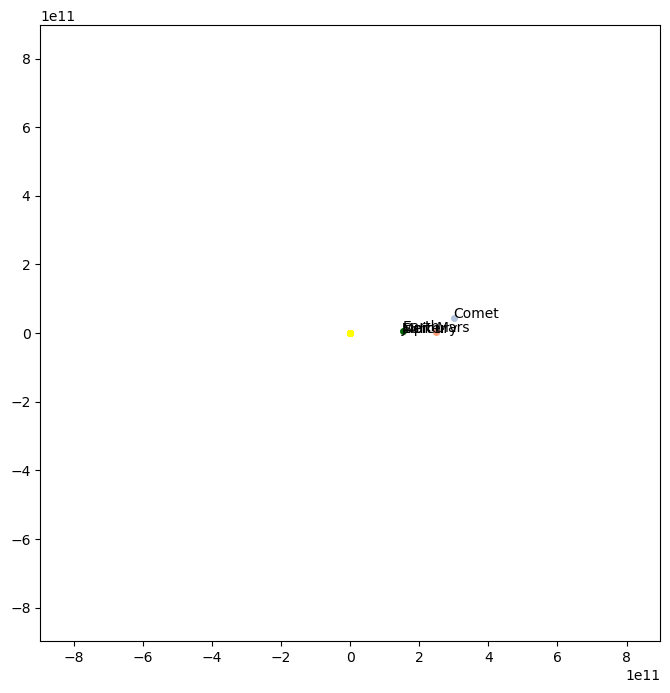

In [47]:
#THE animation
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8,8))

#unpacking the lines:
line_e, = ax.plot(xelist,yelist, '-g', lw=1, color = "darkgreen")
line_m, = ax.plot(xmlist,ymlist, '-g', lw=1, color = "lightsalmon")
line_c, = ax.plot(xclist,yclist, '-g', lw=1, color = "lightsteelblue")
line_s, = ax.plot(xslist,yslist, '-g', lw=1, color = "yellow")
line_mr, = ax.plot(xmrlist,ymrlist, '-g', lw=1, color = "pink")
line_j, = ax.plot(xjlist,yjlist, '-g', lw=1, color = "red")

#unpacking points:
point_e, = ax.plot(xelist,yelist,'bo',markersize=4, color = "darkgreen")
point_m, = ax.plot(xmlist,ymlist,'bo',markersize=4, color = "lightsalmon")
point_c, = ax.plot(xclist,yclist,'bo',markersize=4, color = "lightsteelblue")
point_s, = ax.plot(xslist,yslist,'bo',markersize=4, color = "yellow")
point_mr, = ax.plot(xmrlist, ymrlist,'bo',markersize=4, color = "pink")
point_j, = ax.plot(xjlist,yjlist,'bo',markersize=4, color = "red")

#text for object
text_e = ax.text(AU,0,'Earth')
text_m = ax.text(AU,0,'Mars')
text_c = ax.text(AU,0,'Comet')
text_s = ax.text(AU,0,'Sun')
text_mr = ax.text(AU,0,'Mercury')
text_j = ax.text(AU,0,'Jupiter')

plt.xlim(-6 * AU, 6 * AU)
plt.ylim(-6 * AU, 6 * AU)

def update(frame):
    """
    will update each of the lines, points and pieces of text
    """
    #earth
    line_e.set_data(xelist[:frame], yelist[:frame])
    point_e.set_data(xelist[frame], yelist[frame])
    text_e.set_position((xelist[frame],yelist[frame]))

    #mars
    line_m.set_data(xmlist[:frame], ymlist[:frame])
    point_m.set_data(xmlist[frame], ymlist[frame])
    text_m.set_position((xmlist[frame],ymlist[frame]))

    #comet
    line_c.set_data(xclist[:frame], yclist[:frame])
    point_c.set_data(xclist[frame], yclist[frame])
    text_c.set_position((xclist[frame],yclist[frame]))

    #mercury
    line_mr.set_data(xmrlist[:frame], ymrlist[:frame])
    point_mr.set_data(xmrlist[frame], ymrlist[frame])
    text_mr.set_position((xmrlist[frame],ymrlist[frame]))

    #jupiter
    line_j.set_data(xjlist[:frame], yjlist[:frame])
    point_j.set_data(xjlist[frame], yjlist[frame])
    text_j.set_position((xjlist[frame],yjlist[frame]))

    #sun
    line_s.set_data(xslist[:frame], yslist[:frame])
    point_s.set_data(xslist[frame], yslist[frame])
    text_s.set_position((xslist[frame],yslist[frame]))
    
    return line_e, line_m, line_c, line_s, point_e, point_m, point_c, point_s, text_e, text_m, text_c, text_s, line_mr, point_mr, text_mr, line_j, text_j, point_j, 

ani = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit =True)
plt.show()


Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [32]:
# Your code here
ani.save("orbits2.gif", writer="pillow", fps=10)

C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\832493190.py:39: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xelist[frame], yelist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\832493190.py:44: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xmlist[frame], ymlist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\832493190.py:49: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_c.set_data(xclist[frame], yclist[frame])
C:\Users\jacek\AppData\Local\Temp\ipykernel_39024\832493190.py:54: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_mr.set_data(xmrlist[frame], ymrli

Upload this notebook and your animations to Gradescope!